In [1]:
#import all of the packages

from herbie import FastHerbie
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os

In [2]:
#dataset from other notebook, so we don't have to keep running it
ds_a = xr.open_dataset("ecmwf_20260323.nc")
ds_b = xr.open_dataset("ecmwf_20260323Mar.nc")
ds2 = xr.merge([ds_a, ds_b], compat = 'override')
ds2

sh: 1: getfattr: not found
sh: 1: getfattr: not found


<xarray.Dataset> Size: 80kB
Dimensions:            (valid_time: 15, latitude: 11, longitude: 24)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 120B 2026-03-23 ... 2026-0...
  * latitude           (latitude) float64 88B 42.25 42.0 41.75 ... 40.0 39.75
  * longitude          (longitude) float64 192B -80.5 -80.25 ... -75.0 -74.75
    time               datetime64[ns] 8B ...
    step               (valid_time) timedelta64[ns] 120B ...
    heightAboveGround  float64 8B ...
    surface            float64 8B ...
Data variables:
    fg10               (valid_time, latitude, longitude) float32 16kB ...
    tp                 (valid_time, latitude, longitude) float32 16kB ...
    sf                 (valid_time, latitude, longitude) float32 16kB ...
    t2m                (valid_time, latitude, longitude) float32 16kB ...
    d2m                (valid_time, latitude, longitude) float32 16kB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-01T17:12 GRIB to CDM+CF via cfgrib-0.9.1...

In [3]:
temp=ds2['t2m'] #variable for temperature from the data set
snow=ds2['sf'] #variable for snowfall from the data set
dew=ds2['d2m'] #variable for dew point temperature from the data set
wind_gust=ds2['fg10'] #variable for wind gusts from the data set
precip=ds2['tp'] #variable for total precip from the data set

ValueError: x and y must have same first dimension, but have shapes (15,) and (11, 24)

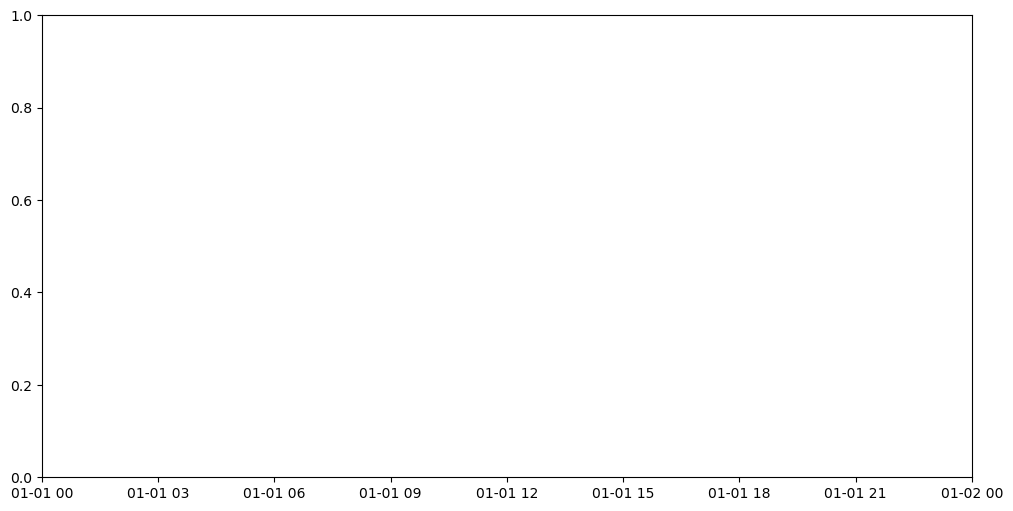

In [4]:
import numpy as np
import matplotlib.pyplot as plt


# 1. VARIABLES

#unit conversions
temp_F = (temp - 273.15) * 9/5 + 32
dew_F = (dew - 273.15) * 9/5 + 32
precip_mm = precip * 1000
wind_mph = wind_gust * 2.237
snow_mm = snow * 1000
times = ds2['valid_time'].values

#Relavtive Humidity Def: 
def calc_rh(T, Td):
    return 100 * np.exp((17.625 * Td)/(243.04 + Td)) / np.exp((17.625 * T)/(243.04 + T))

#Wet Bulb Def: 
def wet_bulb_temp(T, RH):
    return T * np.arctan(0.151977 * (RH + 8.313659)**0.5) + \
           np.arctan(T + RH) - np.arctan(RH - 1.676331) + \
           0.00391838 * RH**1.5 * np.arctan(0.023101 * RH) - 4.686035

def wbgt_calc(T, Tw):
    return 0.7 * Tw + 0.3 * T

# Store results
precip_risk = []
wind_risk = []
wbgt_risk = []
field_risk = []

times = ds2['valid_time'].values #variable for valid times

for t in range(len(times)):

    T = temp_F.isel(valid_time=t) #finding the valid times for each variable for the sake of the hazard
    Td = dew_F.isel(valid_time=t)
    P = precip_mm.isel(valid_time=t)
    S = snow_mm.isel(valid_time=t)
    W = wind_mph.isel(valid_time=t)

    total = T.size #size of the data collection

 
    # WBGT
    
    RH = calc_rh(T, Td)
    Tw = wet_bulb_temp(T, RH)
    WBGT = wbgt_calc(T, Tw)

    wbgt_low25 = (WBGT <= 25).sum() / total * 100 #hazard level for wet bulb
    wbgt_low32 = (WBGT <= 32).sum() / total * 100
#to put on the graph of what level each hazard is
    if wbgt_low25 > 75: 
        wbgt_risk.append(100)
    elif wbgt_low25 >= 40 or wbgt_low32 > 75:
        wbgt_risk.append(60)
    else:
        wbgt_risk.append(20)

   
    # FIELD CONDITIONS
   
    heavy_precip = (P >= 5).sum() / total * 100 #same thing but for precip
    any_precip = (P >= 0.5).sum() / total * 100
    snow_cover = (S >= 2).sum() / total * 100

    freezing = (T <= 32).sum() / total * 100

    if snow_cover > 50 or heavy_precip > 75:
        field_risk.append(100)
    elif any_precip > 40 or (snow_cover > 25 and freezing < 50):
        field_risk.append(60)
    else:
        field_risk.append(20)

   
    # PRECIP

    heavy = (P >= 5).sum() / total * 100
    moderate = (P >= 2).sum() / total * 100

    if heavy > 75:
        precip_risk.append(100)
    elif moderate >= 40:
        precip_risk.append(60)
    else:
        precip_risk.append(20)

    
    # WIND
    
    strong = (W >= 15).sum() / total * 100

    if strong > 75:
        wind_risk.append(100)
    elif strong >= 40:
        wind_risk.append(60)
    else:
        wind_risk.append(20)

# 3. PLOT


fig, ax = plt.subplots(figsize=(12,6))

ax.plot(times, P, label='Precip Risk', linewidth=2) #plotting each variable by itself, but on the same graph
ax.plot(times, W, label='Wind Risk', linewidth=2)
ax.plot(times, Td, label='WBGT Risk', linewidth=2)
ax.plot(times, T, label='Field Condition Risk', linewidth=2)

# Overall max risk (decision line)
#overall = np.maximum.reduce([precip_risk, wind_risk, wbgt_risk, field_risk])
#ax.plot(times, overall, color='black', linewidth=3, linestyle='--', label='Overall Risk')

# Risk bands
ax.axhspan(75, 100, alpha=0.2)
ax.axhspan(40, 75, alpha=0.1)

ax.set_ylim(0, 100)
ax.set_ylabel('Risk (%)')
ax.set_xlabel('Forecast Time')
ax.set_title(
    f"Game Cancellation Risk Assessment (Multi-Factor)\n"
    f"Inital: {np.datetime_as_string(ds2['time'], unit='h')}\n"
    f"Valid: {np.datetime_as_string(ds2['valid_time'].values[-1], unit='h')}"
)

ax.legend()
plt.xticks(rotation=45)
from matplotlib.colors import Normalize
import matplotlib.cm as cm

# Create normalization (0–100%)
norm = Normalize(vmin=0, vmax=100)

# Blue colormap
cmap = cm.Blues

# Create a ScalarMappable for the colorbar
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

# Add background shading using same cmap
ax.axhspan(0, 40, color=cmap(norm(20)), alpha=0.3)
ax.axhspan(40, 75, color=cmap(norm(60)), alpha=0.3)
ax.axhspan(75, 100, color=cmap(norm(90)), alpha=0.3)

# Add colorbar
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Risk Level (%)')

plt.tight_layout()
plt.show()

In [6]:
times

array(['2026-03-23T00:00:00.000000000', '2026-03-23T06:00:00.000000000',
       '2026-03-23T12:00:00.000000000', '2026-03-23T18:00:00.000000000',
       '2026-03-24T00:00:00.000000000', '2026-03-24T06:00:00.000000000',
       '2026-03-24T12:00:00.000000000', '2026-03-24T18:00:00.000000000',
       '2026-03-25T00:00:00.000000000', '2026-03-25T06:00:00.000000000',
       '2026-03-25T12:00:00.000000000', '2026-03-25T18:00:00.000000000',
       '2026-03-26T00:00:00.000000000', '2026-03-26T06:00:00.000000000',
       '2026-03-26T12:00:00.000000000'], dtype='datetime64[ns]')

In [7]:
P

<xarray.DataArray 'tp' (latitude: 11, longitude: 24)> Size: 1kB
array([[ 2.670288  ,  2.3040771 ,  1.9836426 ,  2.3498535 ,  2.8839111 ,
         3.8604736 ,  4.058838  ,  2.8686523 ,  2.243042  ,  2.1820068 ,
         2.1362305 ,  2.609253  ,  7.659912  ,  2.7770996 ,  3.1280518 ,
         4.5318604 ,  5.0964355 ,  4.776001  ,  4.623413  ,  5.92041   ,
         5.3710938 ,  6.149292  ,  9.613037  ,  7.30896   ],
       [ 2.89917   ,  3.463745  ,  2.2888184 ,  2.2277832 ,  2.380371  ,
         2.5177002 ,  2.89917   ,  3.5858154 ,  2.609253  ,  1.8157959 ,
         2.1820068 ,  2.4414062 ,  2.960205  ,  3.2348633 ,  2.822876  ,
         3.3721924 ,  3.7841797 ,  4.257202  ,  4.9591064 ,  4.9438477 ,
         5.4626465 ,  6.2561035 ,  7.3242188 ,  7.797241  ],
       [ 2.1362305 ,  2.3040771 ,  1.5106201 ,  1.7547607 ,  1.7547607 ,
         2.380371  ,  2.6245117 ,  2.3651123 ,  3.7078857 ,  2.822876  ,
         2.3651123 ,  2.7618408 ,  3.112793  ,  3.8909912 ,  4.6691895 ,
         5.3710938 ,  6.652832  ,  6.378174  ,  5.8135986 ,  6.42395   ,
         7.1411133 ,  7.30896   ,  7.675171  ,  8.743286  ],
       [ 0.90026855,  1.8615723 ,  3.7841797 ,  2.9907227 ,  5.142212  ,
         4.760742  ,  4.0893555 ,  5.203247  ,  4.5928955 ,  5.6152344 ,
         5.4473877 ,  5.4779053 ,  5.783081  ,  6.439209  ,  6.958008  ,
         6.8511963 ,  7.9803467 , 14.724731  ,  8.773804  ,  9.887695  ,
        10.910034  , 11.154175  , 12.8479    , 18.371582  ],
...
         9.933472  ,  8.666992  ,  7.537842  ,  7.461548  , 10.879517  ,
         8.605957  ,  9.475708  ,  8.865356  , 11.734009  ,  9.0789795 ,
        12.557983  ,  9.887695  ,  9.109497  ,  9.399414  , 10.681152  ,
        11.428833  , 12.588501  , 11.703491  , 20.812988  ],
       [10.71167   , 10.025024  , 12.252808  ,  8.728027  ,  7.507324  ,
        10.1623535 , 10.650635  ,  6.9732666 ,  9.170532  ,  6.210327  ,
         7.385254  ,  6.515503  ,  6.011963  ,  6.378174  ,  6.1035156 ,
         7.537842  ,  8.010864  ,  9.567261  ,  9.857178  ,  8.773804  ,
         8.895874  , 11.550903  , 13.793945  ,  9.536743  ],
       [11.398315  , 10.192871  ,  7.0648193 ,  5.584717  ,  5.493164  ,
         4.9591064 ,  5.355835  ,  5.5389404 ,  6.790161  ,  7.1868896 ,
         5.9814453 ,  6.6833496 ,  7.171631  ,  7.3394775 ,  7.095337  ,
         7.507324  ,  8.041382  ,  8.636475  ,  9.765625  , 10.299683  ,
         9.811401  ,  7.369995  , 10.131836  ,  7.1411133 ],
       [ 9.841919  , 16.921997  ,  7.446289  , 12.420654  ,  6.210327  ,
         6.134033  ,  9.094238  ,  6.6070557 ,  5.8135986 ,  5.7678223 ,
         6.3171387 ,  5.5999756 ,  9.353638  ,  7.4005127 ,  9.338379  ,
         7.3547363 ,  8.468628  ,  6.1798096 ,  7.9345703 ,  9.384155  ,
         5.844116  ,  6.713867  ,  6.0577393 ,  6.881714  ]],
      dtype=float32)
Coordinates:
  * latitude           (latitude) float64 88B 42.25 42.0 41.75 ... 40.0 39.75
  * longitude          (longitude) float64 192B -80.5 -80.25 ... -75.0 -74.75
    time               datetime64[ns] 8B ...
    step               timedelta64[ns] 8B ...
    heightAboveGround  float64 8B ...
    valid_time         datetime64[ns] 8B 2026-03-26T12:00:00
    surface            float64 8B ...
Attributes: (12/30)
    GRIB_paramId:                             228
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            accum
    ...                                       ...
    GRIB_name:                                Total precipitation
    GRIB_shortName:                           tp
    GRIB_units:                               m
    long_name:                                Total precipitation
    units:                                    m
    standard_name:                            unknown

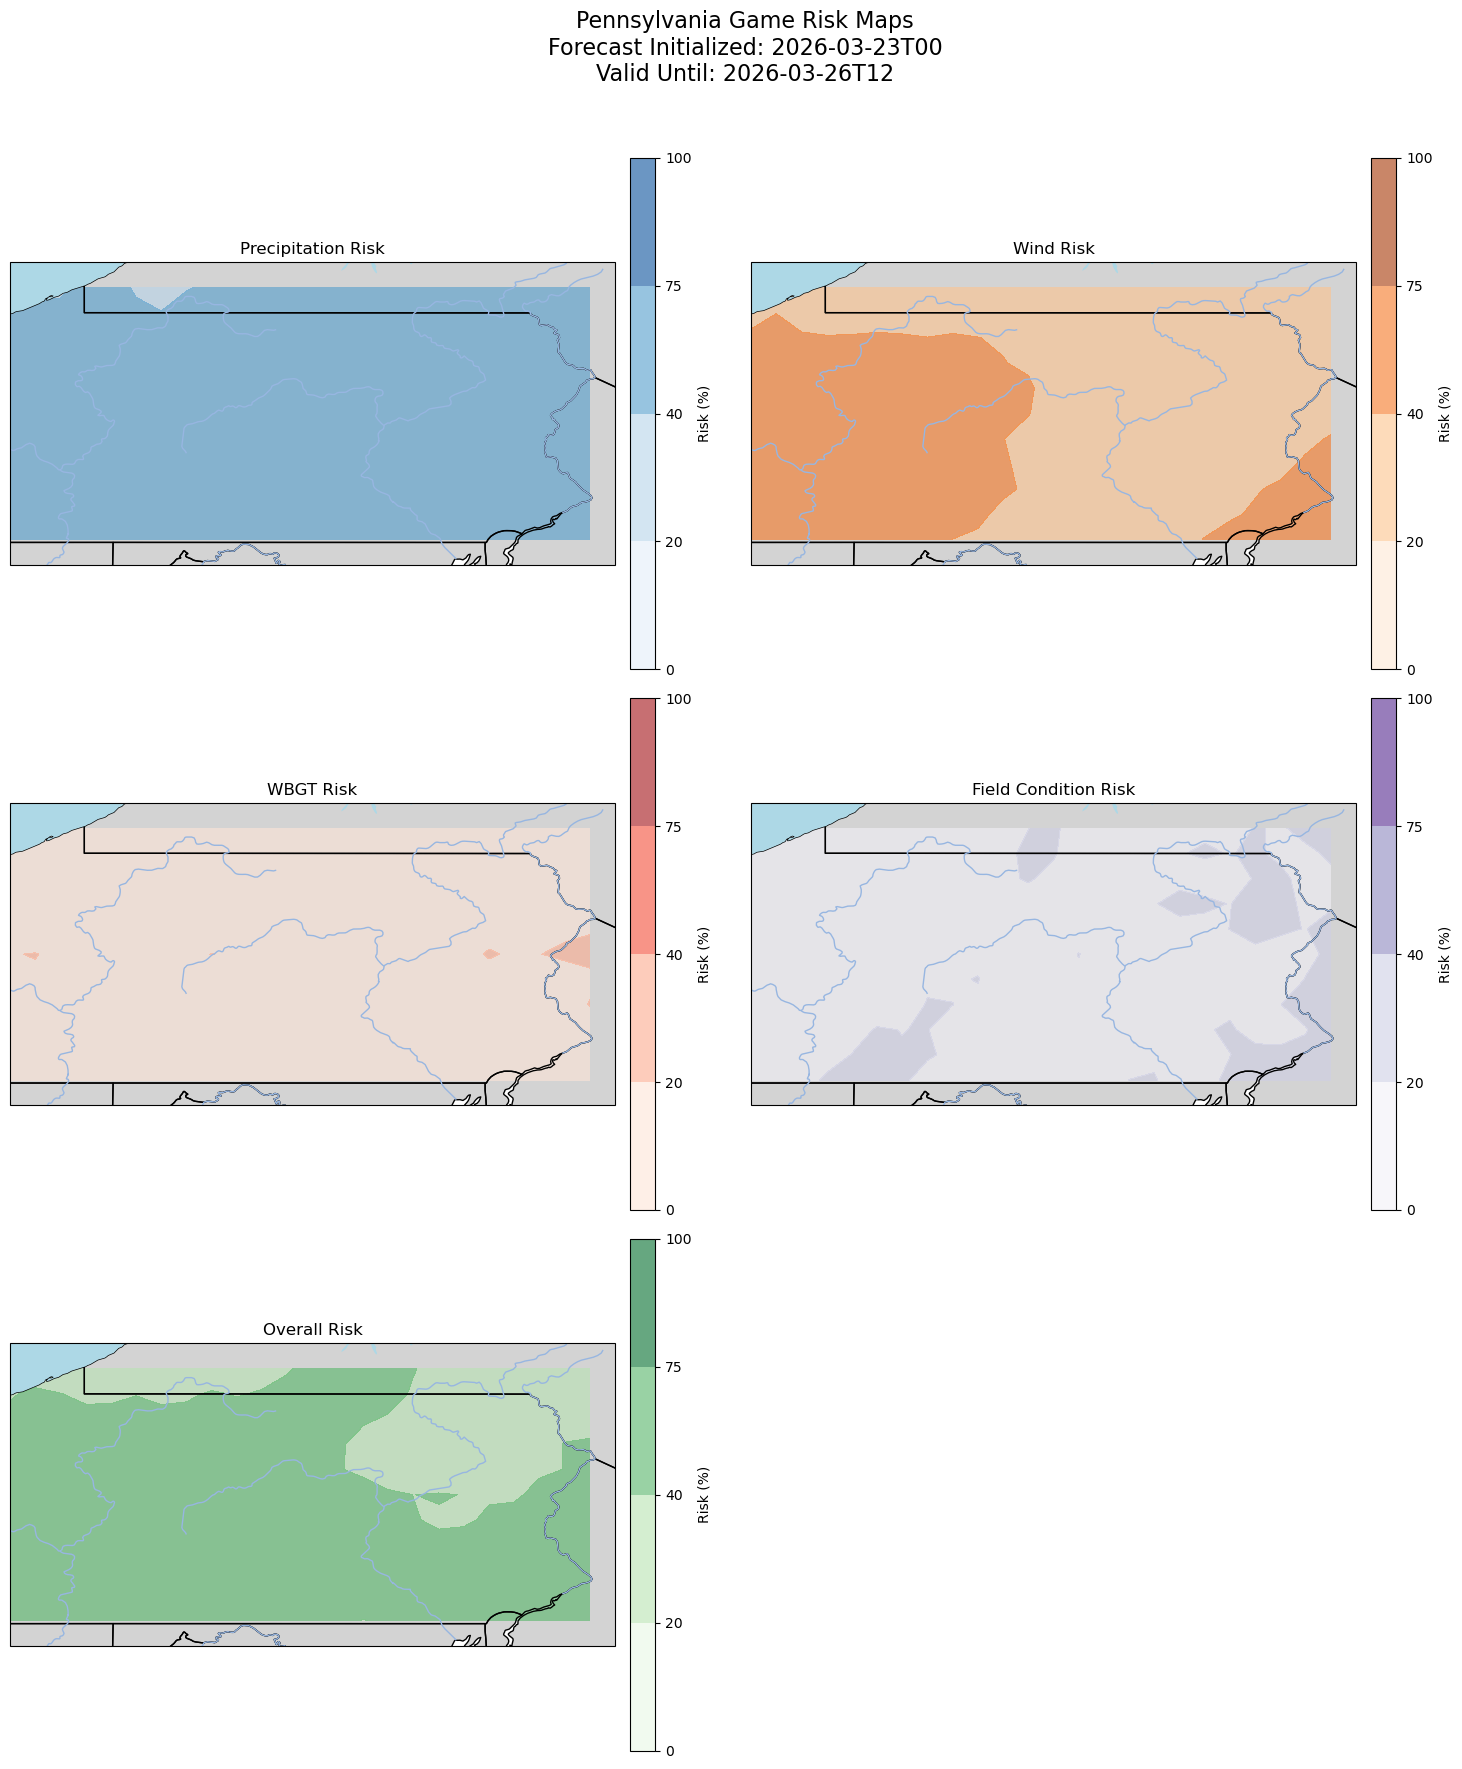

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# 1. Select the PA region

lat_min, lat_max = 39.5, 42.5
lon_min, lon_max = -80.5, -74.5


# 2. Extract last forecast step

tp = ds2['tp'].sel(valid_time=ds2['valid_time'].values[-1], method='nearest') #total precip
fg10 = ds2['fg10'].sel(valid_time=ds2['valid_time'].values[-1], method='nearest') #10 m gusts
d2m = ds2['d2m'].sel(valid_time=ds2['valid_time'].values[-1], method='nearest') #dew point
t2m = ds2['t2m'].sel(valid_time=ds2['valid_time'].values[-1], method='nearest') #temp
sf = ds2['sf'].sel(valid_time=ds2['valid_time'].values[-1], method='nearest')       # snowfall

lons = ds2['longitude'].values
lats = ds2['latitude'].values
LON, LAT = np.meshgrid(lons, lats) #proper lon and lat for PA


# 3. Compute risk per grid point

# Example thresholds (same idea as your previous code)
precip_risk_map = np.where(tp > 5, 100, 20)        # precipitation threshold
wind_risk_map = np.where(fg10 > 15, 100, 20)      # strong wind threshold
wbgt_risk_map = np.where((t2m > 30) & (d2m > 20), 100, 20)  # WBGT heat risk
field_risk_map = np.where(sf > 0, 100, 20)        # snow on field

# Overall risk = max of all risks
overall_risk_map = np.maximum.reduce([precip_risk_map, wind_risk_map, wbgt_risk_map, field_risk_map])


# 4. Plot all risk maps

fig, axes = plt.subplots(3, 2, figsize=(15, 18),
                         subplot_kw={'projection': ccrs.PlateCarree()}) #PlateCaree is type of map projection
axes = axes.flatten()

risk_maps = [T, Td, P, W, WBGT]
titles = ['Precipitation Risk', 'Wind Risk', 'WBGT Risk', 'Field Condition Risk', 'Overall Risk']
colors = ['Blues', 'Oranges', 'Reds', 'Purples', 'Greens']

for ax, risk, title, cmap in zip(axes, risk_maps, titles, colors):
    ax.set_extent([lon_min, lon_max, lat_min, lat_max])
    ax.add_feature(cfeature.STATES, edgecolor='black')
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.LAKES, facecolor='lightblue')
    ax.add_feature(cfeature.RIVERS) #all of these add_features are to make the map cooler
    
    c = ax.contourf(LON, LAT, risk, levels=[0,20,40,75,100], cmap=cmap, alpha=0.6) #contourf is type of plot
    cb = plt.colorbar(c, ax=ax, orientation='vertical', pad=0.02)
    cb.set_label('Risk (%)')
    ax.set_title(title)

# Remove last empty subplot (axes[5]) if not used
fig.delaxes(axes[-1])

# ==============================
# 5. Add overall title
# ==============================
time_initial = ds2['time'].values
time_end = ds2['valid_time'].values[-1]

fig.suptitle(
    f"Pennsylvania Game Risk Maps\nForecast Initialized: {np.datetime_as_string(time_initial, unit='h')}\n"
    f"Valid Until: {np.datetime_as_string(time_end, unit='h')}",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

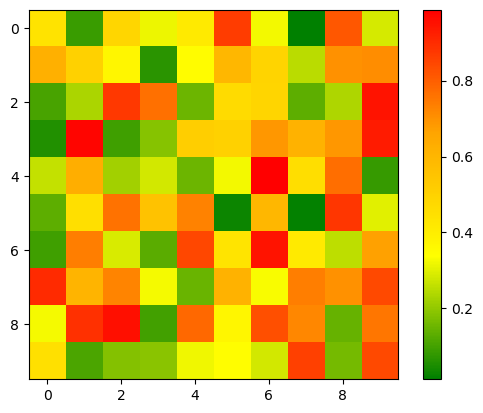

In [10]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Define colors
colors = ["green", "yellow", "orange", "red"]

# Create colormap
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors)

# Example usage
data = np.random.rand(10, 10)
plt.imshow(data, cmap=cmap)
plt.colorbar()
plt.show()